In [1]:
# PAS TRÈS PRATIQUE!!.
# Leave the RIKS1 and RISK3 with negative values.
# Take abs(y_train) because 'CM' and 'CHARGE' have to be positive.

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import re  # Make sure to import the re module

In [3]:
# Charger les données
print("Chargement des données...")
X_train = pd.read_csv("train_input_Z61KlZo.csv")
y_train = pd.read_csv("train_output_DzPxaPY.csv")
X_test = pd.read_csv("test_input_5qJzHrr.csv")
print("Données chargées avec succès.")
# Attention: des colonnes comme 'FRCH1' contiennent des str et float à la fois, d'où les messages en bas. 

Chargement des données...


/tmp/ipykernel_24272/3647256335.py:3: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_train = pd.read_csv("train_input_Z61KlZo.csv")
/tmp/ipykernel_24272/3647256335.py:5: DtypeWarning: Columns (16,17,29,30,31,126,128,129,132,133,135,138,371) have mixed types. Specify dtype option on import or set low_memory=False.
  X_test = pd.read_csv("test_input_5qJzHrr.csv")


Données chargées avec succès.


### y_train

In [4]:
y_train.columns

Index(['ID', 'FREQ', 'CM', 'ANNEE_ASSURANCE', 'CHARGE'], dtype='object')

In [5]:
len(y_train[y_train['CHARGE']!=0])/len(y_train)

0.00614686791272386

0.614% de 'CHARGE' sont non nulles. Il serait alors préférable de commencer par un algo de classification ensuite prédiction de la valeur exacte de 'CHARGE'.

In [6]:
# Certaines valeurs sont négative dans y_train.
y_train=y_train.abs()

### Dropping features with few info

In [7]:
#The proportions of null are equal between train and test. Get rid of some columns to make life simpler

# Calculate percentage of nulls per column
null_train = (X_train.isnull().sum() / len(X_train)) * 100
null_test = (X_test.isnull().sum() / len(X_test)) * 100

# Convert to DataFrame for better display
null = pd.DataFrame({'column': null_train.index, 'null_train': null_train.values,'null_test': null_test.values })
col_drop=null[null['null_test']>55]['column'].to_list()

#drop the columns
X_train = X_train.drop(columns=col_drop, axis=1)
X_test = X_test.drop(columns=col_drop, axis=1)


In [8]:
print('The dropped features are:', col_drop)
print('Number of features dropped:', len(col_drop))
print('Number of features is now:', len(X_train.columns)-1)

The dropped features are: ['CARACT2', 'CARACT3', 'TYPBAT1', 'DEROG12', 'DEROG13', 'DEROG14', 'DEROG16', 'DISTANCE_111', 'DISTANCE_112', 'DISTANCE_121', 'DISTANCE_122', 'DISTANCE_123', 'DISTANCE_124', 'DISTANCE_131', 'DISTANCE_132', 'DISTANCE_133', 'DISTANCE_141', 'DISTANCE_142', 'DISTANCE_211', 'DISTANCE_212', 'DISTANCE_213', 'DISTANCE_221', 'DISTANCE_222', 'DISTANCE_223', 'DISTANCE_231', 'DISTANCE_242', 'DISTANCE_243', 'DISTANCE_244', 'DISTANCE_311', 'DISTANCE_312', 'DISTANCE_313', 'DISTANCE_321', 'DISTANCE_322', 'DISTANCE_323', 'DISTANCE_324', 'DISTANCE_331', 'DISTANCE_332', 'DISTANCE_333', 'DISTANCE_334', 'DISTANCE_335', 'DISTANCE_411', 'DISTANCE_412', 'DISTANCE_421', 'DISTANCE_422', 'DISTANCE_423', 'DISTANCE_511', 'DISTANCE_512', 'DISTANCE_521', 'DISTANCE_522', 'DISTANCE_523', 'DISTANCE_1', 'DISTANCE_2', 'ALTITUDE_1', 'BDTOPO_BAT_MAX_HAUTEUR_MAX', 'HAUTEUR', 'HAUTEUR_MAX', 'BDTOPO_BAT_MAX_HAUTEUR', 'NBJTX25_MM_A', 'NBJTX25_MMAX_A', 'NBJTX25_MSOM_A', 'NBJTX0_MM_A', 'NBJTX0_MMAX_A', 

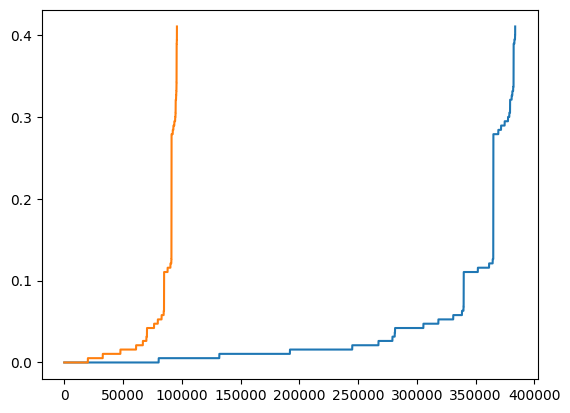

In [9]:
# Few Nan's left, their distribution is similar between Trai and Test
nan_counts = X_train.isna().sum(axis=1)/190
nan_counts_test = X_test.isna().sum(axis=1)/190
plt.plot(sorted(nan_counts.tolist()))
plt.plot(sorted(nan_counts_test.tolist()))

### Encoding

In [10]:
# Identifier les colonnes numériques
numeric_cols = X_train.select_dtypes(include=['number']).columns

# Identifier les colonnes non numériques
nnumeric_cols = [item for item in X_train.columns if item not in numeric_cols]

In [11]:
print('Numeric columns:',numeric_cols)

Numeric columns: Index(['ID', 'TYPERS', 'ANCIENNETE', 'DUREE_REQANEUF', 'CARACT5', 'TYPBAT2',
       'DEROG15', 'CA1', 'CA2', 'CA3', 'KAPITAL1', 'KAPITAL2', 'KAPITAL3',
       'KAPITAL4', 'KAPITAL5', 'KAPITAL6', 'KAPITAL7', 'KAPITAL8', 'KAPITAL9',
       'KAPITAL10', 'KAPITAL11', 'KAPITAL12', 'KAPITAL13', 'KAPITAL14',
       'KAPITAL15', 'KAPITAL16', 'KAPITAL17', 'KAPITAL18', 'KAPITAL19',
       'KAPITAL20', 'KAPITAL21', 'KAPITAL22', 'KAPITAL23', 'KAPITAL24',
       'KAPITAL25', 'KAPITAL26', 'KAPITAL27', 'KAPITAL28', 'KAPITAL29',
       'KAPITAL30', 'KAPITAL31', 'KAPITAL32', 'KAPITAL33', 'SURFACE1',
       'SURFACE2', 'SURFACE3', 'SURFACE5', 'SURFACE7', 'SURFACE8', 'SURFACE9',
       'SURFACE10', 'SURFACE11', 'SURFACE12', 'SURFACE13', 'SURFACE14',
       'SURFACE15', 'SURFACE16', 'SURFACE17', 'SURFACE18', 'SURFACE19',
       'SURFACE20', 'SURFACE21', 'NBBAT1', 'NBBAT2', 'NBBAT3', 'NBBAT4',
       'NBBAT5', 'NBBAT6', 'NBBAT7', 'NBBAT8', 'NBBAT9', 'NBBAT10', 'NBBAT11',
       'NBBAT13', 

In [12]:
print('Non numeric columns:', nnumeric_cols)

Non numeric columns: ['ACTIVIT2', 'VOCATION', 'ADOSS', 'CARACT1', 'INDEM1', 'CARACT4', 'INDEM2', 'FRCH1', 'FRCH2', 'DEROG1', 'DEROG2', 'DEROG3', 'DEROG4', 'DEROG5', 'DEROG6', 'DEROG7', 'DEROG8', 'DEROG9', 'DEROG10', 'DEROG11', 'TAILLE1', 'TAILLE2', 'KAPITAL34', 'KAPITAL35', 'KAPITAL36', 'KAPITAL37', 'KAPITAL38', 'KAPITAL39', 'KAPITAL40', 'KAPITAL41', 'KAPITAL42', 'KAPITAL43', 'SURFACE4', 'SURFACE6', 'COEFASS', 'RISK6', 'RISK8', 'RISK9', 'RISK10', 'RISK11', 'RISK12', 'RISK13', 'EQUIPEMENT2', 'EQUIPEMENT5', 'PROPORTION_11', 'PROPORTION_12', 'PROPORTION_13', 'PROPORTION_14', 'PROPORTION_21', 'PROPORTION_22', 'PROPORTION_23', 'PROPORTION_24', 'PROPORTION_31', 'PROPORTION_32', 'PROPORTION_33', 'PROPORTION_41', 'PROPORTION_42', 'PROPORTION_51', 'PROPORTION_52', 'MEN', 'MEN_PAUV', 'MEN_1IND', 'MEN_5IND', 'MEN_PROP', 'MEN_FMP', 'MEN_COLL', 'MEN_MAIS', 'LOG_AVA1', 'LOG_A1_A2', 'LOG_A2_A3', 'LOG_APA3', 'LOG_INC', 'LOG_SOC', 'IND', 'IND_0_Y1', 'IND_Y1_Y2', 'IND_Y2_Y3', 'IND_Y3_Y4', 'IND_Y4_Y5', '

In [13]:
# Remplir les NaN avec 0 pour les colonnes numériques
X_train[numeric_cols] = X_train[numeric_cols].fillna(0.)
X_test[numeric_cols] = X_test[numeric_cols].fillna(0.)

In [14]:
# Encoding ACTIVIT2
activity_values = ['ACT1', 'ACT2', 'ACT5', 'ACT8', 'ACT9', 'ACT6', 'ACT7', 'ACT3', 'ACT4']

# Create the mapping using dictionary comprehension
activity_mapping = {val: idx+1 for idx, val in enumerate(sorted(activity_values))}

# Show the mapping
print("Activity Mapping:", activity_mapping)

# Apply the mapping to the 'Activity' column of the DataFrame
X_train['ACTIVIT2'] = X_train['ACTIVIT2'].map(activity_mapping)
X_train['ACTIVIT2']= X_train['ACTIVIT2'].astype(float)
X_test['ACTIVIT2'] = X_test['ACTIVIT2'].map(activity_mapping)
X_test['ACTIVIT2']= X_test['ACTIVIT2'].astype(float)

Activity Mapping: {'ACT1': 1, 'ACT2': 2, 'ACT3': 3, 'ACT4': 4, 'ACT5': 5, 'ACT6': 6, 'ACT7': 7, 'ACT8': 8, 'ACT9': 9}


In [15]:
# Encoding VOCATION
voc_values = ['VOC6', 'VOC7', 'VOC1', 'VOC4', 'VOC8', 'VOC3', 'VOC5', 'VOC2']

# Create the mapping using dictionary comprehension
voc_mapping = {val: idx+1 for idx, val in enumerate(sorted(voc_values))}

# Apply the mapping to the 'VOC' column of the DataFrame
X_train['VOCATION'] = X_train['VOCATION'].map(voc_mapping)
X_test['VOCATION'] = X_test['VOCATION'].map(voc_mapping)

# Convert the encoded values to float
X_train['VOCATION'] = X_train['VOCATION'].astype(float)
X_test['VOCATION'] = X_test['VOCATION'].astype(float)

In [16]:
# Encode FRCH1, carefull, it has both str and objects in its values !! 
def encode_frch(val):
    if isinstance(val, str):  # If the value is a string
        if val.isdigit():  # If it's a string of digits like '1', '0', '2'
            return int(val)  # Convert it to integer
        else:
            return np.nan  # Handle the unexpected 'i' by setting it as NaN
    return val  # If it's already an integer, return it as is

# Apply the encoding function to the column
X_train['FRCH1'] = X_train['FRCH1'].apply(encode_frch)
X_test['FRCH1'] = X_test['FRCH1'].apply(encode_frch)

# Replace NaN values with a placeholder (e.g., -1)
X_train['FRCH1'] = X_train['FRCH1'].fillna(-5)
X_test['FRCH1'] = X_test['FRCH1'].fillna(-5)

In [17]:
# Encode FRCH2
frch2_mapping = {
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    'A': 10
}

# Apply the mapping to the 'Category' column of the DataFrame
X_train['FRCH2'] = X_train['FRCH2'].map(frch2_mapping)
X_test['FRCH2'] = X_test['FRCH2'].map(frch2_mapping)

# Fill NaN values with -1
X_train['FRCH2'] = X_train['FRCH2'].fillna(-1)
X_test['FRCH2'] = X_test['FRCH2'].fillna(-1)

# Convert the column to float
X_train['FRCH2'] = X_train['FRCH2'].astype(float)
X_test['FRCH2'] = X_test['FRCH2'].astype(float)

In [18]:
#Encode CARACT1
# Create the mapping for 'N', 'R', 'O', and np.nan
category_mapping = {'N': 1, 'R': 2, 'O': 3}

# Apply the mapping to the 'Category' column of the DataFrame
X_train['CARACT1'] = X_train['CARACT1'].map(category_mapping)
X_test['CARACT1'] = X_test['CARACT1'].map(category_mapping)

# Fill NaN values with -1
X_train['CARACT1'] = X_train['CARACT1'].fillna(-1)
X_test['CARACT1'] = X_test['CARACT1'].fillna(-1)

# Convert the column to float
X_train['CARACT1'] = X_train['CARACT1'].astype(float)
X_test['CARACT1'] = X_test['CARACT1'].astype(float)


In [19]:
# 'SURFACE4' = 'SURFACE6' ALWAYS!!!
X_train=X_train.drop(columns='SURFACE6') 
X_test=X_test.drop(columns='SURFACE6') 

# Define the function to handle the data transformation of 'SURFACE4'
def encode_value(val):
    # If the value contains a '+' (i.e., '7000+'), replace it with 10000
    if isinstance(val, str) and '+' in val:
        return 10000.0  # Convert to float as per requirement
    else:
        # Convert the numeric values to float
        return float(val)
        
# Apply the encoding function to the data
X_train['SURFACE4'] = X_train['SURFACE4'].apply(encode_value)
X_test['SURFACE4'] = X_test['SURFACE4'].apply(encode_value)

In [20]:
# Compute the 'SUMSURF' (we have 2*SURFACE4 coz we removed SURFACE6)
X_train['SUMSURF']= X_train[['SURFACE1',
       'SURFACE2', 'SURFACE3', 'SURFACE5', 'SURFACE7', 'SURFACE8', 'SURFACE9',
       'SURFACE10', 'SURFACE11', 'SURFACE12', 'SURFACE13', 'SURFACE14',
       'SURFACE15', 'SURFACE16', 'SURFACE17', 'SURFACE18', 'SURFACE19',
       'SURFACE20', 'SURFACE21']].sum(axis=1)+2*X_train['SURFACE4']
X_test['SUMSURF']= X_test[['SURFACE1',
       'SURFACE2', 'SURFACE3', 'SURFACE5', 'SURFACE7', 'SURFACE8', 'SURFACE9',
       'SURFACE10', 'SURFACE11', 'SURFACE12', 'SURFACE13', 'SURFACE14',
       'SURFACE15', 'SURFACE16', 'SURFACE17', 'SURFACE18', 'SURFACE19',
       'SURFACE20', 'SURFACE21']].sum(axis=1)+2*X_test['SURFACE4']

/tmp/ipykernel_24272/808123475.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['SUMSURF']= X_train[['SURFACE1',
/tmp/ipykernel_24272/808123475.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['SUMSURF']= X_test[['SURFACE1',


In [21]:
# Custom mappings for the first and second data
mapping1 = {
    'N': 0,
    'R': 1,
    'O': 2,
    np.nan: -1  # Handling NaN with -1
}

mapping2 = {
    'AP': 0,
    'CS': 1,
    'GM': 2,
    'TO': 3,
    'GU': 4,
    'GC': 5,
    'CX': 6,
    'AX': 7,
    np.nan: -1  # Handling NaN with -1
}


# Encode the data using the custom mappings
X_train['EQUIPEMENT2'] = X_train['EQUIPEMENT2'].map(mapping1)
X_train['EQUIPEMENT5'] = X_train['EQUIPEMENT5'].map(mapping2)
X_test['EQUIPEMENT2'] = X_test['EQUIPEMENT2'].map(mapping1)
X_test['EQUIPEMENT5'] = X_test['EQUIPEMENT5'].map(mapping2)

In [22]:
# List of DEROG columns
derog_cols = ['DEROG1', 'DEROG2', 'DEROG3', 'DEROG4', 'DEROG5', 'DEROG6', 'DEROG7', 'DEROG8', 'DEROG9', 'DEROG10', 'DEROG11']

# Replace 'O' with 1 and 'N' with 0
X_train[derog_cols] = X_train[derog_cols].replace({'O': 1.0, 'N': 0.0}).astype(int)
X_test[derog_cols] = X_test[derog_cols].replace({'O': 1.0, 'N': 0.0}).astype(int)

/tmp/ipykernel_24272/4204982582.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[derog_cols] = X_train[derog_cols].replace({'O': 1.0, 'N': 0.0}).astype(int)
/tmp/ipykernel_24272/4204982582.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[derog_cols] = X_test[derog_cols].replace({'O': 1.0, 'N': 0.0}).astype(int)


In [23]:
# X_train[derog_cols].corr()
# Corr(DEROG8,DEROG3) = .995121
#(X_train['DEROG3'] != X_train['DEROG8']).sum() = 83, hence we drop 'DEROG8'
X_train = X_train.drop(columns = 'DEROG8', axis=1)
X_test = X_test.drop(columns = 'DEROG8', axis=1)

In [24]:
# Encode RISKS
ris=['RISK6', 'RISK8', 'RISK9', 'RISK10', 'RISK11', 'RISK12', 'RISK13']

X_train[ris] = X_train[ris].replace({'O': 1, 'N': 0, 'A': 1, 'R': 2})
X_train[ris] = X_train[ris].fillna(-1).infer_objects().astype(int)

X_test[ris] = X_test[ris].replace({'O': 1, 'N': 0, 'A': 1, 'R': 2})
X_test[ris] = X_test[ris].fillna(-1).infer_objects().astype(int)


/tmp/ipykernel_24272/2413922876.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[ris] = X_train[ris].replace({'O': 1, 'N': 0, 'A': 1, 'R': 2})
/tmp/ipykernel_24272/2413922876.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[ris] = X_test[ris].replace({'O': 1, 'N': 0, 'A': 1, 'R': 2})


In [25]:
risks=['RISK1', 'RISK2', 'RISK3', 'RISK4', 'RISK5', 'RISK7', 'RISK6', 'RISK8', 'RISK9', 'RISK10', 'RISK11', 'RISK12', 'RISK13']
X_train[risks].corr()
,

''

In [26]:
# Sum RISKS before dropping
X_train['RIS']= X_train[risks].sum(axis=1)
X_test['RIS']= X_test[risks].sum(axis=1)

#drop redundancy
riskdrop=['RISK2', 'RISK3', 'RISK4', 'RISK5']
X_train = X_train.drop(columns=riskdrop, axis=1)
X_test = X_test.drop(columns=riskdrop, axis=1)

/tmp/ipykernel_24272/992823898.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['RIS']= X_train[risks].sum(axis=1)
/tmp/ipykernel_24272/992823898.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['RIS']= X_test[risks].sum(axis=1)


In [27]:
# List of KAPITAL columns
kap=  ['KAPITAL34', 'KAPITAL35', 'KAPITAL36', 'KAPITAL37', 'KAPITAL38', 'KAPITAL39', 'KAPITAL40', 'KAPITAL41', 'KAPITAL42', 'KAPITAL43']

# Replace 'O' with 1 and 'N' with 0
X_train[kap] = X_train[kap].replace({'O': 1.0, 'N': 0.0}).infer_objects().astype(int)
X_test[kap]  = X_test[kap].replace({'O': 1.0, 'N': 0.0}).infer_objects().astype(int)

/tmp/ipykernel_24272/3123257048.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[kap] = X_train[kap].replace({'O': 1.0, 'N': 0.0}).infer_objects().astype(int)
/tmp/ipykernel_24272/3123257048.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[kap]  = X_test[kap].replace({'O': 1.0, 'N': 0.0}).infer_objects().astype(int)


In [28]:
Kaps = ['KAPITAL34', 'KAPITAL35', 'KAPITAL36', 'KAPITAL37', 'KAPITAL38', 'KAPITAL39', 'KAPITAL40', 'KAPITAL41', 'KAPITAL42', 'KAPITAL43',
       'KAPITAL1', 'KAPITAL2', 'KAPITAL3',
       'KAPITAL4', 'KAPITAL5', 'KAPITAL6', 'KAPITAL7', 'KAPITAL8', 'KAPITAL9',
       'KAPITAL10', 'KAPITAL11', 'KAPITAL12', 'KAPITAL13', 'KAPITAL14',
       'KAPITAL15', 'KAPITAL16', 'KAPITAL17', 'KAPITAL18', 'KAPITAL19',
       'KAPITAL20', 'KAPITAL21', 'KAPITAL22', 'KAPITAL23', 'KAPITAL24',
       'KAPITAL25', 'KAPITAL26', 'KAPITAL27', 'KAPITAL28', 'KAPITAL29',
       'KAPITAL30']
corr_matrix = X_train[Kaps].corr().abs()  # take absolute value if you don't care about direction

# Remove self-correlations by setting lower triangle + diagonal to NaN
upper = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape)).astype(bool))

# Extract pairs with correlation > 0.9
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_1', 'level_1': 'Feature_2', 0: 'Correlation'})
)

# Filter only those with correlation > 0.9
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.9]

print(high_corr_pairs)

     Feature_1  Feature_2  Correlation
47   KAPITAL35   KAPITAL1     1.000000
59   KAPITAL35  KAPITAL13     0.991832
85   KAPITAL36   KAPITAL2     1.000000
122  KAPITAL37   KAPITAL3     1.000000
158  KAPITAL38   KAPITAL4     1.000000
193  KAPITAL39   KAPITAL5     1.000000
227  KAPITAL40   KAPITAL6     1.000000
260  KAPITAL41   KAPITAL7     1.000000
292  KAPITAL42   KAPITAL8     1.000000
323  KAPITAL43   KAPITAL9     1.000000
356   KAPITAL1  KAPITAL13     0.991832
570  KAPITAL10  KAPITAL11     1.000000


In [29]:
# Compute the missing values, then remove those with more missingness
X_train[Kaps].isna().sum()
,

''

In [30]:
# Sum Kapitals
X_train['KAP']=X_train[Kaps].sum(axis=1)
X_test['KAP']=X_test[Kaps].sum(axis=1)

# Drop redundancy 
kapdrop=['KAPITAL1', 'KAPITAL2', 'KAPITAL3', 'KAPITAL4', 'KAPITAL5','KAPITAL6','KAPITAL7','KAPITAL8','KAPITAL9','KAPITAL11',
         'KAPITAL3']
X_train = X_train.drop(columns=kapdrop, axis=1)
X_test = X_test.drop(columns=kapdrop, axis=1)

/tmp/ipykernel_24272/2278381312.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train['KAP']=X_train[Kaps].sum(axis=1)
/tmp/ipykernel_24272/2278381312.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test['KAP']=X_test[Kaps].sum(axis=1)


On va laisser toutes les propotions et pas enlever les correlations, car on en aura besoin dans le feature enge

In [31]:
prop= ['PROPORTION_11', 'PROPORTION_12', 'PROPORTION_13', 'PROPORTION_14', 'PROPORTION_21'
       , 'PROPORTION_22', 'PROPORTION_23', 'PROPORTION_24', 'PROPORTION_31', 'PROPORTION_32', 'PROPORTION_33'
       , 'PROPORTION_41', 'PROPORTION_42', 'PROPORTION_51', 'PROPORTION_52']

mapping = {
    '01. <= 10': 1,
    '02. <= 20': 2,
    '03. <= 30': 3,
    '04. <= 40': 4,
    '05. <= 50': 5,
    '06. <= 60': 6,
    '07. <= 70': 7,
    '08. <= 80': 8,
    '09. <= 90': 9,
    '10. > 90': 10
}

for col in prop:
    X_train[col] = X_train[col].map(mapping).fillna(-1).astype(int)
    X_test[col] = X_test[col].map(mapping).fillna(-1).astype(int)

In [32]:
#Other variables

def mapping(df) :
    df['ADOSS'] = df['ADOSS'].map({'N': 0.0, 'O': 1.0}).fillna(0.0)
    df['ESPINSEE'] =df['ESPINSEE'].map({'ESP3':3.0, 'ESP4':4.0, 'ESP2':2.0, 'ESP1':1.0}).fillna(0.0)
    df['AN_EXERC'] = df['AN_EXERC'].map({'ANNEE5': 5.0, 'ANNEE4':4.0, 'ANNEE3':3.0, 'ANNEE2':2.0, 'ANNEE1':1.0, 
                                     'ANNEE6':6.0, 'ANNEE9': 9.0, 'ANNEE8': 8.0, 'ANNEE7':7.0}).fillna(0.0)
    df['CARACT4'] = df['CARACT4'].map({'absence de surface':0.0, 'Surface de moins d':500.0, 'Surface entre 501':1000.0,
       'Surface entre 1001':1500.0, 'Surface entre 1501':2000.0, 'Surface de plus de':3000.0}).fillna(0.0)
    df['INDEM1'] = df['INDEM1'].map({ 'N': 0.0, 'O': 1.0
    }).fillna(0.0)
    df['INDEM2']=df['INDEM2'].map({'CLASS5':5.0, 'CLASS6':6.0, 'CLASS8':8.0, 'CLASS9':9.0, 'CLASS7':7.0, 'CLASS1':1.0,
       'CLASS13':13.0, 'CLASS2':2.0, 'CLASS11':11.0, 'CLASS4':4.0, 'CLASS10':10.0, 'CLASS3':3.0}).fillna(0.0)
    df['COEFASS']=df['COEFASS'].map({
    '01-10':10.0, '0':0.0, '21-30':30.0, '11-20':20.0, '31-40':40.0, '41-50':50.0
    }).fillna(0.0)
    return df
X_train = mapping(X_train)
X_test = mapping(X_test)

In [33]:
# Function to extract numeric range from the string
def extract_value(text):
    if pd.isna(text):
        return np.nan
    match = re.match(r'(\d+)', text)  # Match the first number in the string
    if match:
        return int(match.group(1))
    return np.nan

In [34]:
#others 
col2 =['TAILLE1','TAILLE2','FFM_VOR_COM_MM_A_Y', 'FFM_VOR_COM_MMAX_A_Y', 'FXI3SAB_VOR_COM_MM_A_Y', 'FXI3SAB_VOR_COM_MMAX_A_Y',
      'IND', 'IND_0_Y1', 'IND_Y1_Y2', 'IND_Y2_Y3', 'IND_Y3_Y4', 'IND_Y4_Y5'
, 'IND_Y5_Y6', 'IND_Y6_Y7', 'IND_Y7_Y8', 'IND_Y8_Y9', 'IND_Y9', 'IND_INC', 'IND_SNV',
        'MEN_SURF', 'ALTITUDE_2', 'ALTITUDE_3', 'ALTITUDE_4', 'ALTITUDE_5', 'NB_CASERNES',
         'MEN', 'MEN_PAUV', 'MEN_1IND', 'MEN_5IND'
         ,'MEN_PROP', 'MEN_FMP', 'MEN_COLL', 'MEN_MAIS', 'LOG_AVA1', 'LOG_A1_A2', 'LOG_A2_A3', 'LOG_APA3', 'LOG_INC', 'LOG_SOC']

# Apply the function to each element in the DataFrame
X_train[col2] = X_train[col2].apply(lambda col: col.map(extract_value))
X_test[col2] = X_test[col2].apply(lambda col: col.map(extract_value))

# Fill NaN values with 0. and ensure the values are float
X_train[col2] = X_train[col2].fillna(0.).astype(float)
X_test[col2] = X_test[col2].fillna(0.).astype(float)

We should be carefull encoding variables like 'TAILLE2', we encode in a naive way, then we re-encode intelligently

En fait, si on codifie 'TAILLE2' avec map on tombe sur Nan's partout.

In [35]:
X_train['TAILLE1'].unique()

array([ 5.,  2.,  1.,  3.,  4.,  6.,  7.,  8., 10.,  9.])

In [36]:
Tmap = {
    5.0: 1500,
    2.0: 500,
    1.0: 250,
    3.0: 750,
    4.0: 1000,
    6.0: 2000,
    7.0: 3000,
    8.0: 4000,
    10.0: 10000,
    9.0: 5000
}

X_train['TAILLE1'] = X_train['TAILLE1'].map(Tmap)
X_train['TAILLE2'] = X_train['TAILLE2'].map(Tmap)
X_test['TAILLE1'] = X_test['TAILLE1'].map(Tmap)
X_test['TAILLE2'] = X_test['TAILLE2'].map(Tmap)

In [37]:
# Check for Nan's
missing_cols = X_test.columns[X_test.isna().any()].tolist()
print(missing_cols)
missing_cols = X_train.columns[X_train.isna().any()].tolist()
print(missing_cols)
# No more Nan's

[]
[]


### More data eng

In [38]:
def data_ing(df):
    # Step 1: Calculate SUMCA and SUMNBBAT
    df['SUMCA'] = df[['CA1', 'CA2', 'CA3']].sum(axis=1)
    df['SUMNBBAT'] = df[['NBBAT1', 'NBBAT2', 'NBBAT3', 'NBBAT4',
                          'NBBAT5', 'NBBAT6', 'NBBAT7', 'NBBAT8', 'NBBAT9', 'NBBAT10', 
                          'NBBAT11', 'NBBAT13', 'NBBAT14']].sum(axis=1)
    
    # Step 2: Create all new columns
    df_new_columns = {
        'CARAT': df['SUMCA'] / (df['SUMSURF'] + 1),
        'DENSBAT': df['SUMNBBAT'] / (df['SUMSURF'] + 1),
        'RATKAP': df['KAP'] / (df['SUMNBBAT'] + 1),
        'RATPAUV': df['MEN_PAUV'] / (df['MEN'] + 1),
        'DENSKAP': df['KAP'] / (df['SUMSURF'] + 1)
    }
    
    # Step 3: Assign the new columns back to the DataFrame at once
    df = pd.concat([df, pd.DataFrame(df_new_columns)], axis=1)
    
    return df

# Apply the function to your data
X_train = data_ing(X_train)
X_test = data_ing(X_test)


/tmp/ipykernel_24272/163224295.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SUMCA'] = df[['CA1', 'CA2', 'CA3']].sum(axis=1)
/tmp/ipykernel_24272/163224295.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['SUMNBBAT'] = df[['NBBAT1', 'NBBAT2', 'NBBAT3', 'NBBAT4',
/tmp/ipykernel_24272/163224295.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. T

### SAVE DATA

In [39]:
# Save the modified data
X_train.to_csv('Xtrain_new.csv', index=False)
X_test.to_csv('Xtest_new.csv', index=False)
y_train.to_csv('ytrain_new.csv', index=False)

In [40]:
X_train.shape,X_test.shape,y_train.shape

((383610, 185), (95852, 185), (383610, 5))

In [41]:
list1 = X_train.columns.tolist() 
list2 = X_test.columns.tolist()
set(list1) - set(list2)

set()

Remove RISK10 coz it has many missing and it is corr to RISK11

Remark: On a des données de surfaces à la fois dans 'CARACT' et 'SURFACE' 

Review how to fill nan's in numeric and non numeric columns